In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageDraw, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import models, transforms
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from PIL import Image, ImageFilter


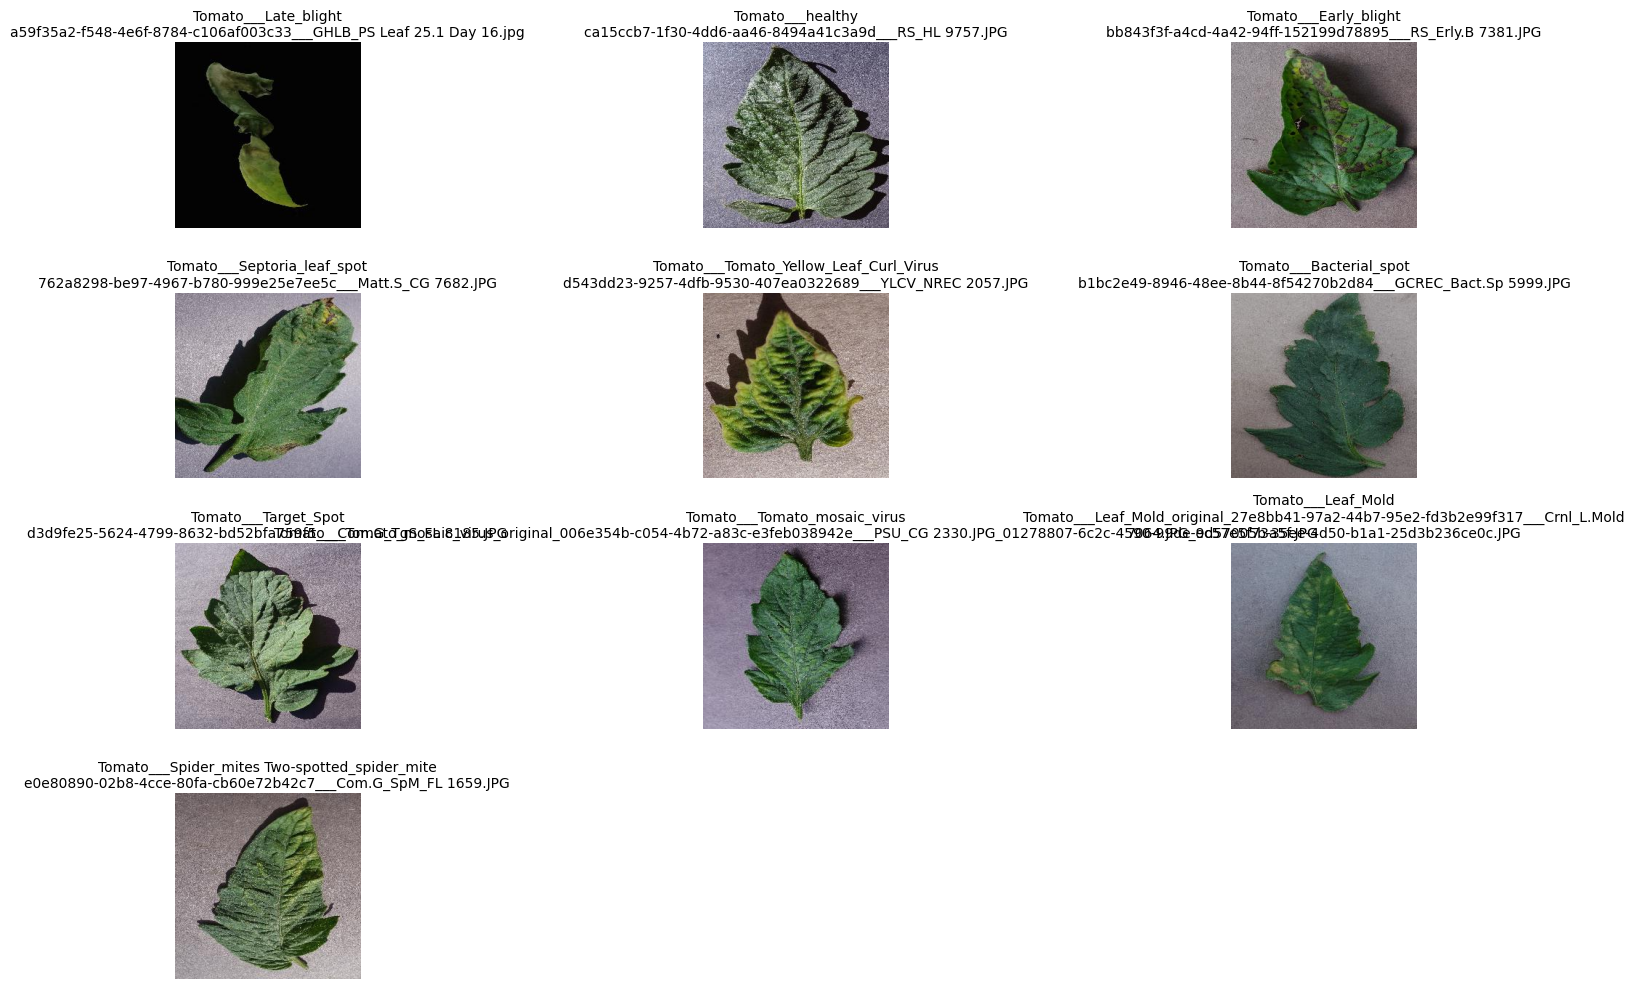

\Chosen imgs:
Tomato___Late_blight: a59f35a2-f548-4e6f-8784-c106af003c33___GHLB_PS Leaf 25.1 Day 16.jpg
Tomato___healthy: ca15ccb7-1f30-4dd6-aa46-8494a41c3a9d___RS_HL 9757.JPG
Tomato___Early_blight: bb843f3f-a4cd-4a42-94ff-152199d78895___RS_Erly.B 7381.JPG
Tomato___Septoria_leaf_spot: 762a8298-be97-4967-b780-999e25e7ee5c___Matt.S_CG 7682.JPG
Tomato___Tomato_Yellow_Leaf_Curl_Virus: d543dd23-9257-4dfb-9530-407ea0322689___YLCV_NREC 2057.JPG
Tomato___Bacterial_spot: b1bc2e49-8946-48ee-8b44-8f54270b2d84___GCREC_Bact.Sp 5999.JPG
Tomato___Target_Spot: d3d9fe25-5624-4799-8632-bd52bfa759f5___Com.G_TgS_FL 8185.JPG
Tomato___Tomato_mosaic_virus: Tomato___Tomato_mosaic_virus_original_006e354b-c054-4b72-a83c-e3feb038942e___PSU_CG 2330.JPG_01278807-6c2c-4590-99de-ec57e5f73a5f.JPG
Tomato___Leaf_Mold: Tomato___Leaf_Mold_original_27e8bb41-97a2-44b7-95e2-fd3b2e99f317___Crnl_L.Mold 7064.JPG_9d57005b-35ee-4d50-b1a1-25d3b236ce0c.JPG
Tomato___Spider_mites Two-spotted_spider_mite: e0e80890-02b8-4cce-80fa-cb60

In [2]:
base_path = '/kaggle/input/tomatoleaf/tomato/train'
def get_random_images_from_folders(base_path, num_samples=1):
    random_images = {}
    folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        images = [f for f in os.listdir(folder_path) 
                 if f.lower().endswith(('.jpg'))]  
        if images:
            selected = random.sample(images, min(num_samples, len(images)))
            random_images[folder] = [os.path.join(folder_path, img) for img in selected]
    return random_images
def visualize_random_samples():
    random_imgs = get_random_images_from_folders(base_path, num_samples=1)
    num_classes = len(random_imgs)
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    axes = axes.flatten()
    for idx, (class_name, img_paths) in enumerate(random_imgs.items()):
        if idx < len(axes):
            img_path = img_paths[0]  
            try:
                img = Image.open(img_path)
                axes[idx].imshow(img)
                axes[idx].set_title(f'{class_name}\n{os.path.basename(img_path)}', 
                              fontsize=10, wrap=True)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Hata: {str(e)}', 
                              transform=axes[idx].transAxes, ha='center')
                axes[idx].set_title(class_name)
    for idx in range(len(random_imgs), len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()
    return random_imgs
def get_multiple_random_samples(base_path, samples_per_class=3):
    return get_random_images_from_folders(base_path, num_samples=samples_per_class)
random_selection = visualize_random_samples()

print("\Chosen imgs:")
for class_name, paths in random_selection.items():
    print(f"{class_name}: {os.path.basename(paths[0])}")

In [3]:
base_path = '/kaggle/input/tomatoleaf/tomato/train'
def get_random_images_from_folders(base_path, num_samples=1):
    random_images = {}
    folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        images = [f for f in os.listdir(folder_path) 
                 if f.lower().endswith(('.jpg'))]  
        if images:
            selected = random.sample(images, min(num_samples, len(images)))
            random_images[folder] = [os.path.join(folder_path, img) for img in selected]
    return random_images
random_Set = get_random_images_from_folders(base_path, num_samples=3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


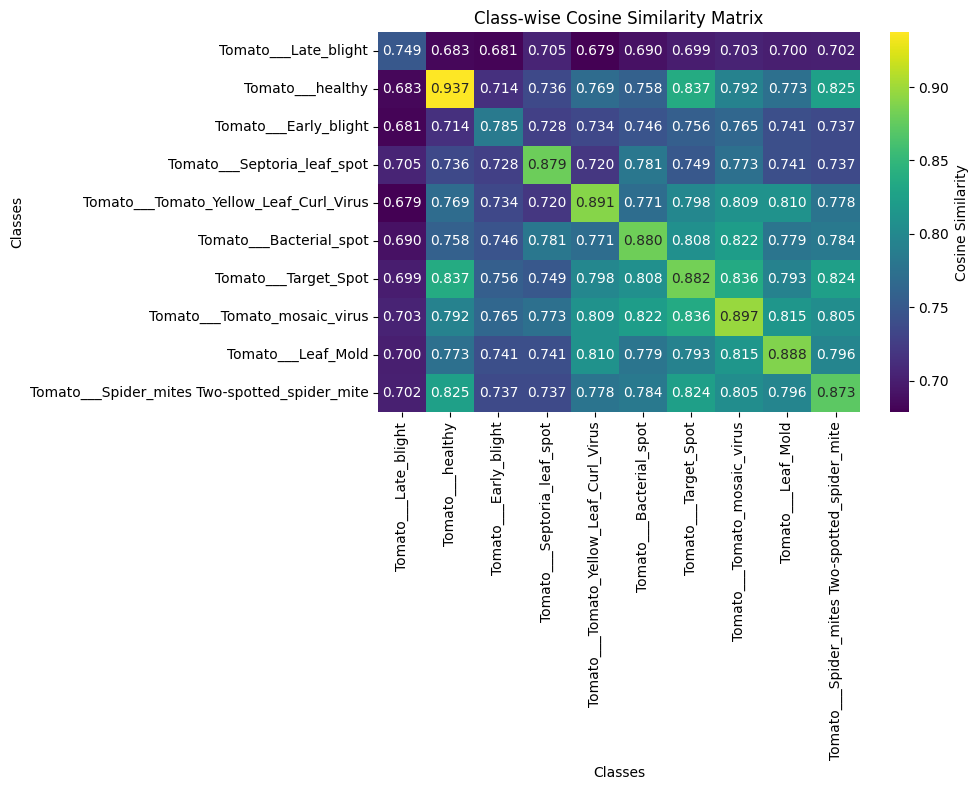

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
cnn = nn.Sequential(*list(cnn.children())[:-1])  
cnn.eval().to(device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

features_dict = {}
with torch.no_grad():
    for cls_name, img_paths in random_Set.items():
        cls_features = []
        for img_path in img_paths:
            img = Image.open(img_path).convert('RGB')
            x = transform(img).unsqueeze(0).to(device)
            feat = cnn(x).squeeze().cpu().numpy()  
            feat = feat / np.linalg.norm(feat)  
            cls_features.append(feat)
        features_dict[cls_name] = np.stack(cls_features)  

all_classes = list(features_dict.keys())
results = {}

for i, cls_i in enumerate(all_classes):
    feats_i = features_dict[cls_i]
    for j, cls_j in enumerate(all_classes):
        feats_j = features_dict[cls_j]
        sim_matrix = cosine_similarity(feats_i, feats_j)  
        results[(cls_i, cls_j)] = sim_matrix.mean()       



sim_matrix_plot = np.zeros((len(all_classes), len(all_classes)))
for i, cls_i in enumerate(all_classes):
    for j, cls_j in enumerate(all_classes):
        sim_matrix_plot[i,j] = results[(cls_i, cls_j)]

plt.figure(figsize=(10,8))
sns.heatmap(sim_matrix_plot, 
           xticklabels=all_classes, 
           yticklabels=all_classes, 
           annot=True, 
           fmt=".3f", 
           cmap="viridis",
           cbar_kws={'label': 'Cosine Similarity'})
plt.title("Class-wise Cosine Similarity Matrix")
plt.xlabel("Classes")
plt.ylabel("Classes")
plt.tight_layout()
plt.show()


non_diagonal_results = {k: v for k, v in results.items() if k[0] != k[1]}
max_similarity = max(non_diagonal_results.items(), key=lambda x: x[1])
min_similarity = min(non_diagonal_results.items(), key=lambda x: x[1])



In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        
        self.register_hooks()

    def register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        forward_handle = self.target_layer.register_forward_hook(forward_hook)
        backward_handle = self.target_layer.register_backward_hook(backward_hook)
        self.hook_handles = [forward_handle, backward_handle]

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        self.model.zero_grad()
        loss = output[0, target_class]
        loss.backward()

        gradients = self.gradients.detach().cpu().numpy()[0]
        activations = self.activations.detach().cpu().numpy()[0]
        weights = np.mean(gradients, axis=(1, 2))
        heatmap = np.zeros(activations.shape[1:])
        for i, w in enumerate(weights):
            heatmap += w * activations[i]
        heatmap = np.maximum(heatmap, 0)
        heatmap = cv2.resize(heatmap, (input_image.shape[3], input_image.shape[2]))
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        return heatmap

    def __del__(self):
        for handle in self.hook_handles:
            handle.remove()

In [6]:
def visualize_gradcam(image_path, model, target_layer, target_class=None):
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(image).unsqueeze(0)
    
    grad_cam = GradCAM(model, target_layer)
    heatmap = grad_cam.generate_heatmap(input_tensor, target_class)
    
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title('Grad-CAM')
    plt.axis('off')
    plt.show()

In [7]:

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)  


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


class TomatoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.images = []
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_path):
                self.images.append((os.path.join(cls_path, img_name), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = TomatoDataset('/kaggle/input/tomatoleaf/tomato/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

num_epochs = 16
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_accuracy = accuracy_score(all_labels, all_preds)
    print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {train_accuracy:.4f}')


torch.save(model.state_dict(), 'tomato_resnet18.pth')

Epoch 1, Loss: 0.7339, Accuracy: 0.7537
Epoch 2, Loss: 0.4151, Accuracy: 0.8578
Epoch 3, Loss: 0.3486, Accuracy: 0.8771
Epoch 4, Loss: 0.2831, Accuracy: 0.9057
Epoch 5, Loss: 0.3017, Accuracy: 0.8990
Epoch 6, Loss: 0.2532, Accuracy: 0.9107
Epoch 7, Loss: 0.2123, Accuracy: 0.9268
Epoch 8, Loss: 0.1971, Accuracy: 0.9334
Epoch 9, Loss: 0.1847, Accuracy: 0.9371
Epoch 10, Loss: 0.2050, Accuracy: 0.9282
Epoch 11, Loss: 0.1902, Accuracy: 0.9349
Epoch 12, Loss: 0.1733, Accuracy: 0.9407
Epoch 13, Loss: 0.1820, Accuracy: 0.9396
Epoch 14, Loss: 0.1873, Accuracy: 0.9345
Epoch 15, Loss: 0.1691, Accuracy: 0.9413
Epoch 16, Loss: 0.1470, Accuracy: 0.9509


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


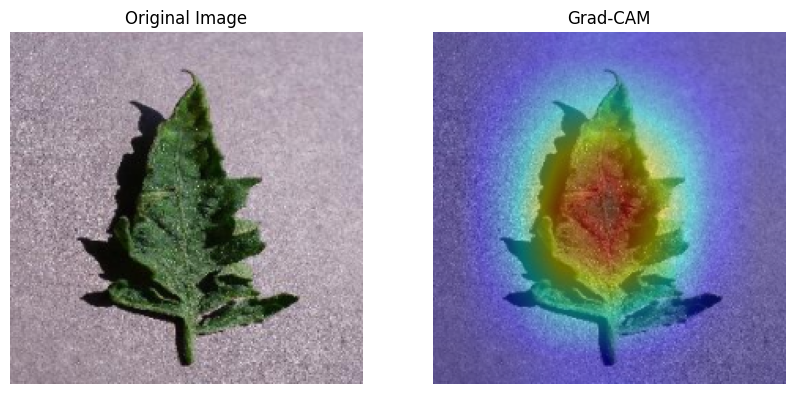

In [8]:
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model.load_state_dict(torch.load('/kaggle/working/tomato_resnet18.pth'))
model.eval()
target_layer = model.layer4[1].conv2
image_path = "/kaggle/input/tomatoleaf/tomato/val/Tomato___Tomato_mosaic_virus/0fefaaee-79e4-45a6-8606-5a4ab1ea43a2___PSU_CG 2398.JPG"
visualize_gradcam(image_path, model, target_layer)

chosen img: /kaggle/input/tomatoleaf/tomato/val/Tomato___Late_blight/Tomato___Late_blight_original_0ba7d3d8-5c4c-4365-ba0c-69f61e96a36e___RS_Late.B 5312.JPG_0c8b3e88-9afa-41e1-a767-122ad7b27ac2.JPG
chosen label: Tomato___Late_blight

DEFORMATION          PREDICTION                          CONFIDENCE CHANGE    
ORIGINAL             Tomato_Late_blight                  1.0000     +0.0000
YELLOW_SPOTS         Tomato_Late_blight                  1.0000     -0.0000
GREEN_EFFECT         Tomato_Late_blight                  1.0000     -0.0000
RED_EFFECT           Tomato_Late_blight                  1.0000     -0.0000
CORNER_ARTIFACTS     Tomato_Late_blight                  1.0000     +0.0000
BACKGROUND_NOISE     Tomato_Late_blight                  0.9999     -0.0001
BLUR                 Tomato_Late_blight                  1.0000     -0.0000


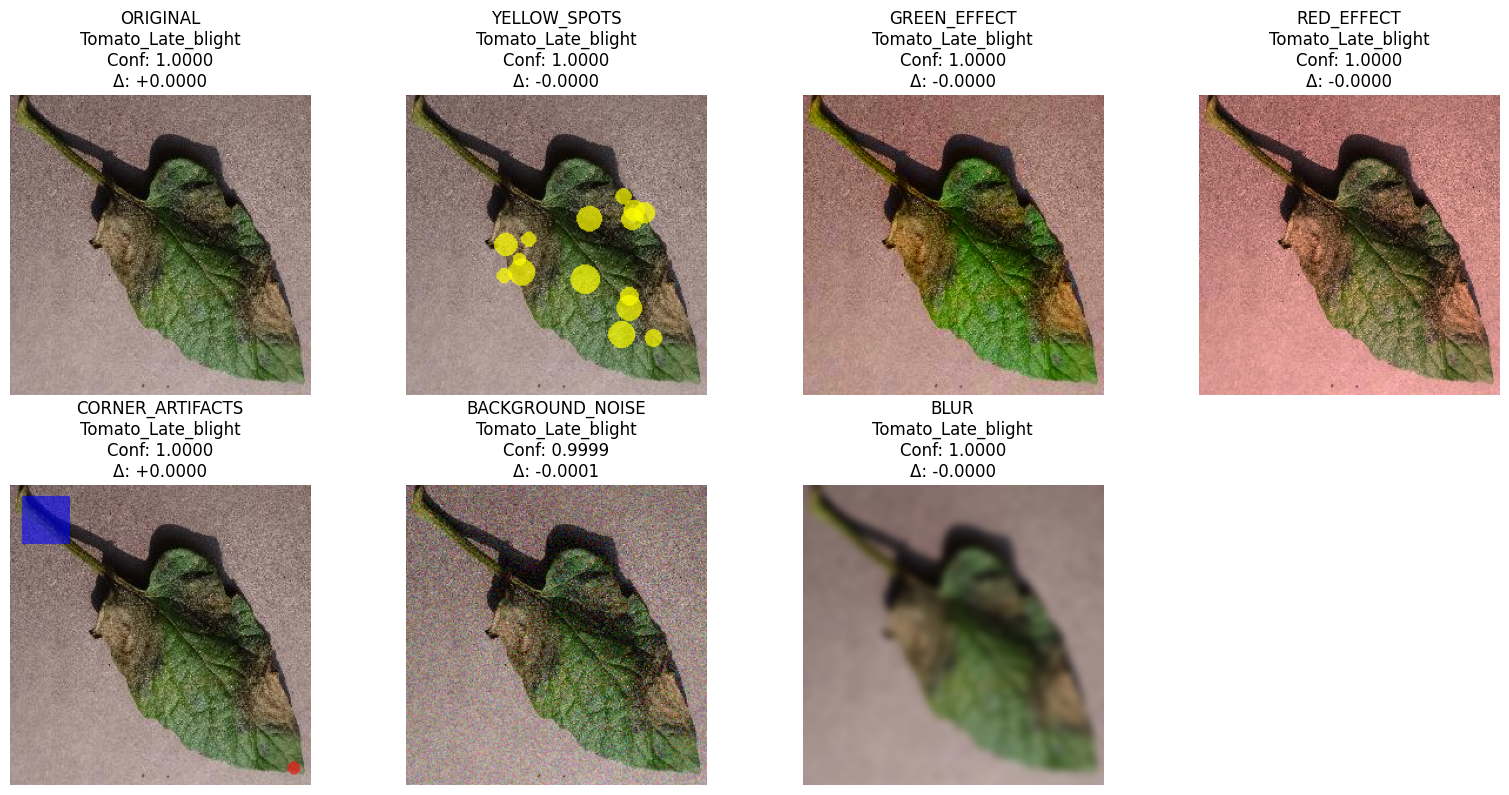

In [9]:
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model.load_state_dict(torch.load('/kaggle/working/tomato_resnet18.pth'))
model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class_names = [
    'Tomato_Late_blight', 'Tomato_healthy', 'Tomato_Early_blight',
    'Tomato_Septoria_leaf_spot', 'Tomato_Tomato_yellow_Leaf_Curl_Virus',
    'Tomato_Bacterial_spot', 'Tomato_Target_Spot', 'Tomato_Tomato_mosaic_virus',
    'Tomato_Leaf_Mold', 'Tomato_Spider_mites Two-spotted_spider_mite'
]


val_path = '/kaggle/input/tomatoleaf/tomato/val'
classes = os.listdir(val_path)
random_class = random.choice(classes)
class_path = os.path.join(val_path, random_class)
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

print(f"chosen img: {img_path}")
print(f"chosen label: {random_class}")

original_img = Image.open(img_path).convert('RGB')

def get_prediction(image):
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_class = torch.argmax(probs).item()
        confidence = probs[pred_class].item()
    return class_names[pred_class], confidence

original_pred, original_conf = get_prediction(original_img)

def add_yellow_spots(img):

    img = img.copy()
    draw = ImageDraw.Draw(img, 'RGBA')
    w, h = img.size
    for _ in range(15):
        x, y = random.randint(50, w-50), random.randint(50, h-50)
        size = random.randint(10, 25)
        draw.ellipse([x, y, x+size, y+size], fill=(255, 255, 0, 180))
    return img

def add_green_effect(img):

    enhancer = ImageEnhance.Color(img)
    return enhancer.enhance(2.0) 

def add_red_effect(img):

    img = img.copy()
    np_img = np.array(img).astype(np.float32)
    np_img[:,:,0] = np.clip(np_img[:,:,0] * 1.3, 0, 255)  
    return Image.fromarray(np_img.astype(np.uint8))

def add_corner_artifacts(img):

    img = img.copy()
    draw = ImageDraw.Draw(img, 'RGBA')
    w, h = img.size

    draw.rectangle([10, 10, 50, 50], fill=(0, 0, 255, 150))

    draw.ellipse([w-20, h-20, w-10, h-10], fill=(255, 0, 0, 150))
    return img

def add_background_noise(img):

    np_img = np.array(img)
    noise = np.random.randint(-30, 30, np_img.shape, dtype=np.int16)
    noisy_img = np.clip(np_img + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy_img)

def blur_image(img):

    return img.filter(ImageFilter.GaussianBlur(radius=3))

deformations = {
    'ORIGINAL': original_img,
    'YELLOW_SPOTS': add_yellow_spots(original_img),
    'GREEN_EFFECT': add_green_effect(original_img),
    'RED_EFFECT': add_red_effect(original_img),
    'CORNER_ARTIFACTS': add_corner_artifacts(original_img),
    'BACKGROUND_NOISE': add_background_noise(original_img),
    'BLUR': blur_image(original_img)
}


print(f"\n{'DEFORMATION':<20} {'PREDICTION':<35} {'CONFIDENCE':<10} {'CHANGE':<10}")
print("="*80)

results = {}
for name, deformed_img in deformations.items():
    pred, conf = get_prediction(deformed_img)
    change = conf - original_conf if name != 'ORİJİNAL' else 0
    results[name] = (pred, conf, change)
    
    print(f"{name:<20} {pred:<35} {conf:.4f}     {change:+.4f}")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (name, deformed_img) in enumerate(deformations.items()):
    if i < len(axes):
        axes[i].imshow(deformed_img)
        pred, conf, change = results[name]
        axes[i].set_title(f"{name}\n{pred}\nConf: {conf:.4f}\nΔ: {change:+.4f}")
        axes[i].axis('off')


 
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


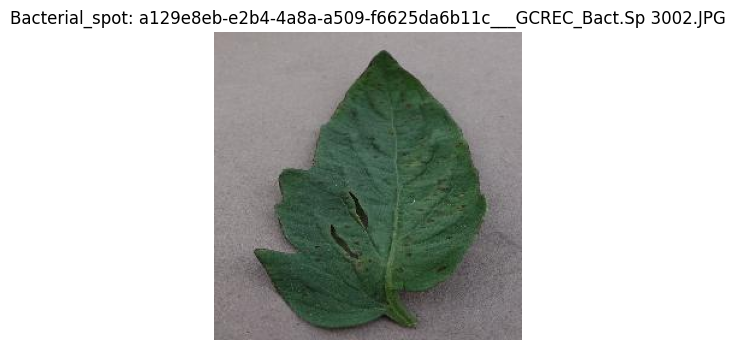

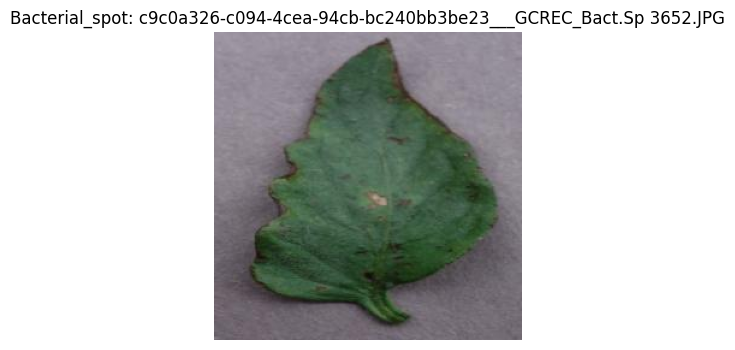

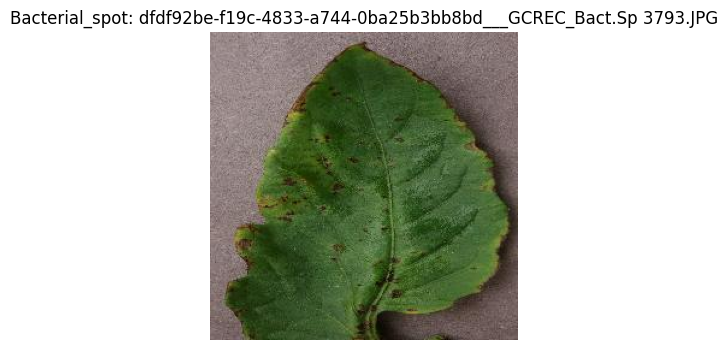

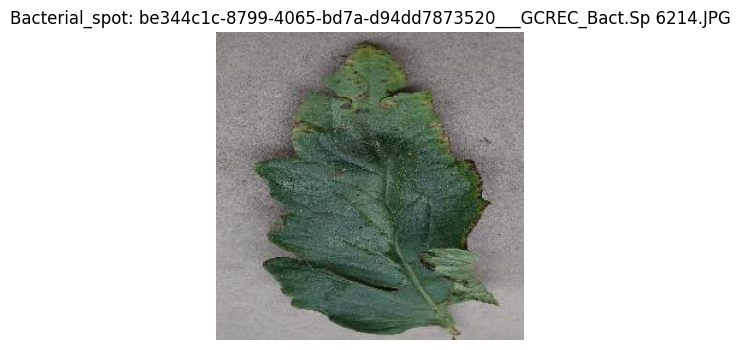

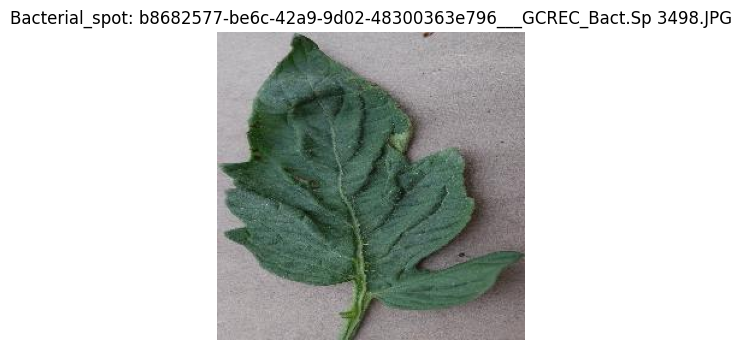

In [10]:
bacterial_path = '/kaggle/input/tomatoleaf/tomato/train/Tomato___Bacterial_spot'
bacterial_images = os.listdir(bacterial_path)[:5]  
for img_name in bacterial_images:
    img = Image.open(os.path.join(bacterial_path, img_name))
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"Bacterial_spot: {img_name}")
    plt.axis('off')
    plt.show()

#  Dataset Augmentation and Overconfidence Analysis
At the beginning, we had a ResNet model. Already in the first epoch, meaning the model had learned almost nothing, it reached an accuracy of 0.86. This indicated that the model had quickly grasped the local manifold. However, keep in mind that our dataset, D, was quite limited and homogeneous: all images were taken under the same studio conditions, with nearly identical lighting and background. The small anomalies relevant to the problem occupied only a tiny portion of the images; therefore, similarity tests naturally returned high values.

To expand this limited dataset, we applied classical augmentation methods, resulting in D’ = A(D). In other words, D’ was created by varying the elements of D. The critical point, however, is that augmentation only operated within the boundaries of D. Hence, D’ cannot fully reach the global manifold E, which represents the ideal set of all possible combinations in the problem space.

Think of this using a Lego analogy: we have a box of Legos, which we call D. The Lego pieces are square, but we are asked to build a sphere — this represents E. We try to construct the elements of D’ using the pieces in the box; each x element is taken from D and combined in new ways. Yet, since the pieces are limited, we can never perfectly approximate the sphere.

E represents the ideal world containing all possible scenarios. D’, however, is constrained to variations of D, covering only a small portion of the global manifold. As a result, the model shows high accuracy on D’ but can make overconfident predictions on examples outside this manifold.

We tested this by applying small perturbations: yellow spots, blur effects, corner artifacts… The results were striking. Some modifications dramatically changed the model’s predictions; in fact, confidence sometimes reached 0.99. Specifically, the yellow spot perturbation caused the model to immediately and confidently predict “Bacterial_spot”. In other words, the model behaves overconfidently outside the local manifold.

Conclusion:

D’ = A(D) cannot reach the global manifold E, remaining limited to D’s boundaries.

High accuracy is reliable only on the local manifold.

Softmax outputs are unreliable outside the local manifold, leading to overconfidence issues.